# CS412 Machine Learning – Homework 1
## Breast Cancer Classification with k-NN and Decision Trees

Student: Poyraz Ünalır

Notebook link: https://github.com/poyrazunalir-source/CS412/blob/main/CS412_HW1_PoyrazUnalir.ipynb


## 1. Dataset Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# 70% train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# remaining 30% -> validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


## 2. Data Analysis

In [ ]:
# Class distribution
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    name = 'malignant' if label == 0 else 'benign'
    print(name, count)

malignant 212
benign 357


In [ ]:
# Basic statistics for first 3 features
print('Mean Radius mean:', np.mean(X[:,0]))
print('Mean Radius std:', np.std(X[:,0]))

print('Mean Texture mean:', np.mean(X[:,1]))
print('Mean Texture std:', np.std(X[:,1]))

print('Mean Perimeter mean:', np.mean(X[:,2]))
print('Mean Perimeter std:', np.std(X[:,2]))

Mean Radius mean: 14.127291739894552
Mean Radius std: 3.520950760711062
Mean Texture mean: 19.289648506151142
Mean Texture std: 4.297254637090421
Mean Perimeter mean: 91.96903339191564
Mean Perimeter std: 24.27761929305318


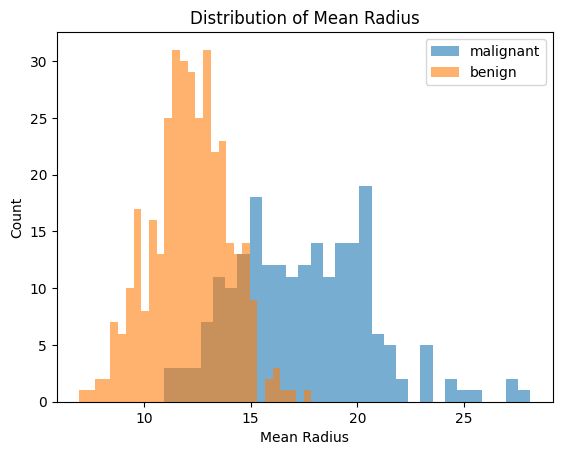

In [ ]:
# Histogram of mean radius
plt.figure()
plt.hist(X[y==0,0], bins=30, alpha=0.6, label='malignant')
plt.hist(X[y==1,0], bins=30, alpha=0.6, label='benign')

plt.xlabel('Mean Radius')
plt.ylabel('Count')
plt.title('Distribution of Mean Radius')
plt.legend()
plt.show()

## 3. Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 4. k-NN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1,3,5,7,9,15,21]
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)

    val_accuracies.append(acc)
    print('k=',k,'accuracy=',acc)

k= 1 accuracy= 0.9176470588235294
k= 3 accuracy= 0.9294117647058824
k= 5 accuracy= 0.9294117647058824
k= 7 accuracy= 0.9294117647058824
k= 9 accuracy= 0.9529411764705882
k= 15 accuracy= 0.9529411764705882
k= 21 accuracy= 0.9529411764705882


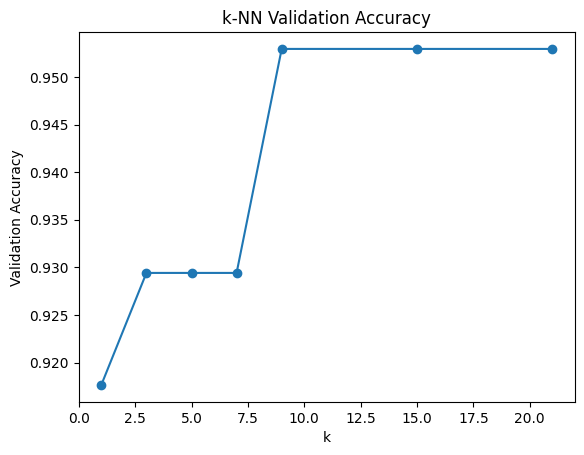

Best k: 9


In [ ]:
plt.plot(k_values, val_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('k-NN Validation Accuracy')
plt.show()

best_k = k_values[np.argmax(val_accuracies)]
print('Best k:', best_k)

## 5. Final k-NN Evaluation

In [ ]:
X_trainval = np.vstack((X_train_scaled, X_val_scaled))
y_trainval = np.hstack((y_train, y_val))

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_trainval, y_trainval)

test_preds = knn_final.predict(X_test_scaled)

print('Test Accuracy:', accuracy_score(y_test, test_preds))

Test Accuracy: 0.9883720930232558


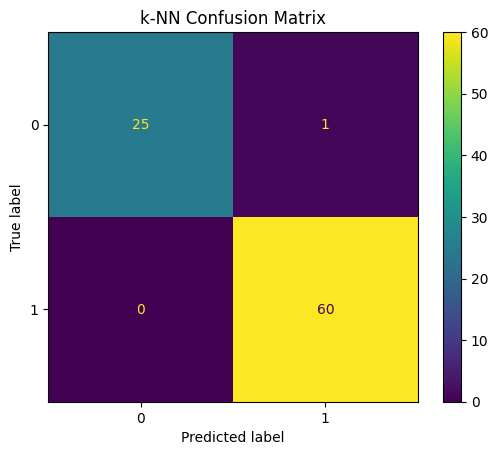

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('k-NN Confusion Matrix')
plt.show()

## 6. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

depth_values = [2,4,6,8,None]
split_values = [2,5,10]

results = []

for depth in depth_values:
    for split in split_values:
        model = DecisionTreeClassifier(max_depth=depth, min_samples_split=split, random_state=42)
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_val_scaled)
        acc = accuracy_score(y_val, preds)

        results.append((depth, split, acc))
        print(depth, split, acc)

best = max(results, key=lambda x: x[2])
best_depth, best_split, best_acc = best

print('Best depth:', best_depth)
print('Best min_samples_split:', best_split)

2 2 0.9176470588235294
2 5 0.9176470588235294
2 10 0.9176470588235294
4 2 0.9647058823529412
4 5 0.9411764705882353
4 10 0.9411764705882353
6 2 0.9647058823529412
6 5 0.9529411764705882
6 10 0.9529411764705882
8 2 0.9411764705882353
8 5 0.9411764705882353
8 10 0.9294117647058824
None 2 0.9411764705882353
None 5 0.9411764705882353
None 10 0.9294117647058824
Best depth: 4
Best min_samples_split: 2


## 7. Final Decision Tree

In [ ]:
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_split,
    random_state=42
)

dt_final.fit(X_trainval, y_trainval)

dt_preds = dt_final.predict(X_test_scaled)

print('Decision Tree Test Accuracy:', accuracy_score(y_test, dt_preds))

Decision Tree Test Accuracy: 0.9534883720930233


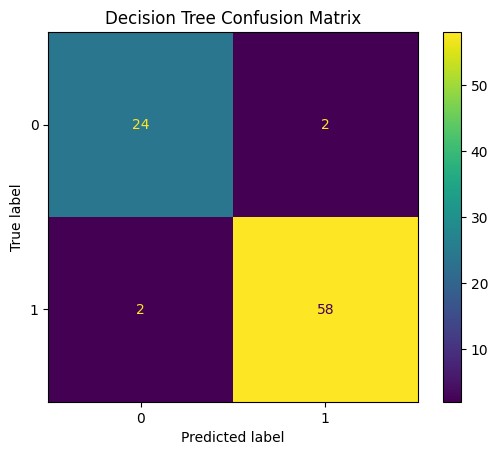

In [ ]:
cm = confusion_matrix(y_test, dt_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

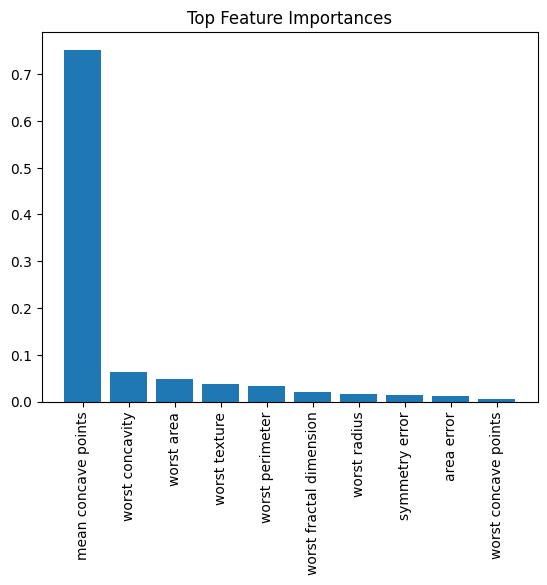

In [ ]:
# Feature importance
importances = dt_final.feature_importances_

indices = np.argsort(importances)[::-1][:10]

plt.figure()
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), feature_names[indices], rotation=90)

plt.title('Top Feature Importances')
plt.show()